In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, classification_report

# 1. Load and Combine
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')
true_df['target'] = 0
fake_df['target'] = 1
df = pd.concat([true_df, fake_df]).reset_index(drop=True)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target'], test_size=0.2, random_state=42)

# 3. Performance Dashboard Function
performance_results = {}

def evaluate_model(y_true, y_probs, model_name):
    y_pred = (y_probs > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    performance_results[model_name] = acc

    print(f"\n===== {model_name} Performance =====")
    print(f"Accuracy: {acc * 100:.2f}%")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'Confusion Matrix: {model_name}')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    ax[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
    ax[1].plot([0, 1], [0, 1], '--')
    ax[1].set_title(f'ROC Curve: {model_name}')
    ax[1].legend()
    plt.show()


===== Naive Bayes Performance =====
Accuracy: 93.18%


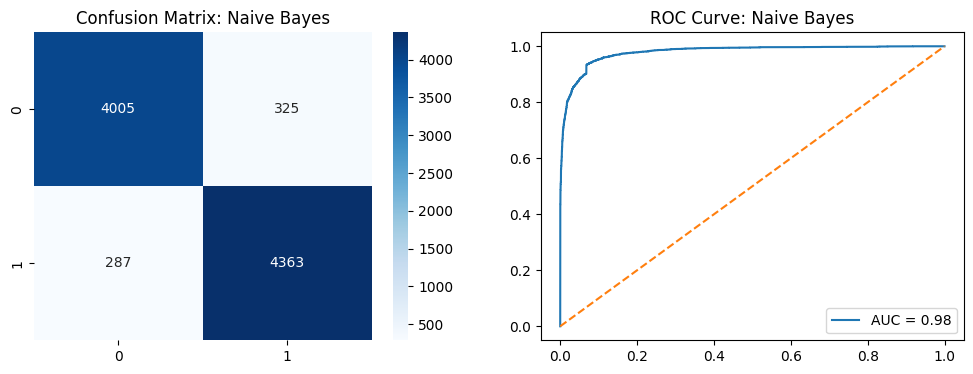


===== SVM Performance =====
Accuracy: 99.37%


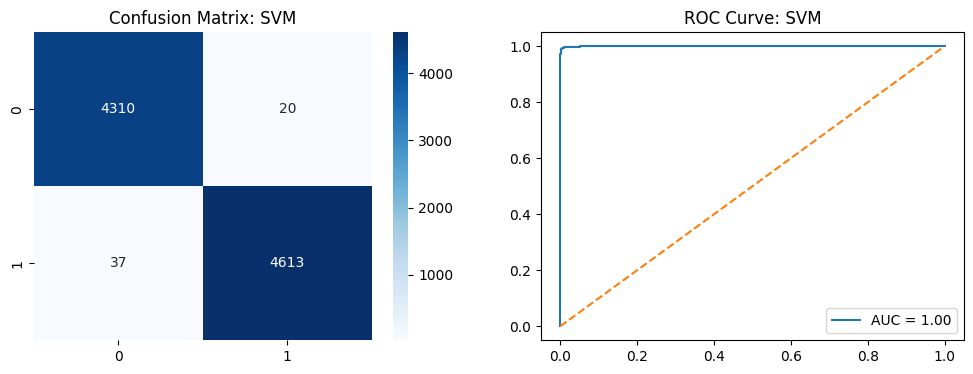

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 1. Naive Bayes
nb = MultinomialNB().fit(X_train_tfidf, y_train)
evaluate_model(y_test, nb.predict_proba(X_test_tfidf)[:, 1], "Naive Bayes")

# 2. SVM (using LinearSVC with Calibration for probabilities)
svm = CalibratedClassifierCV(LinearSVC()).fit(X_train_tfidf, y_train)
evaluate_model(y_test, svm.predict_proba(X_test_tfidf)[:, 1], "SVM")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9481 - loss: 0.1323
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9899 - loss: 0.0369
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9873 - loss: 0.0418
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step

===== LSTM Performance =====
Accuracy: 98.50%


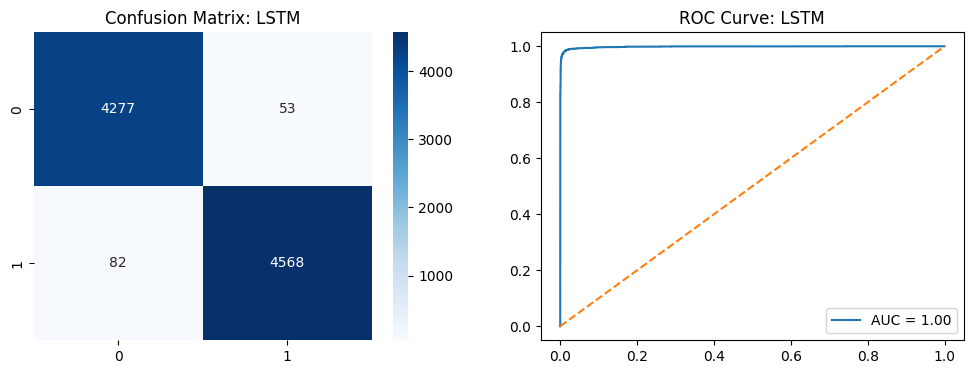

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

# Tokenize
token = Tokenizer(num_words=10000)
token.fit_on_texts(X_train)
X_train_seq = pad_sequences(token.texts_to_sequences(X_train), maxlen=300)
X_test_seq = pad_sequences(token.texts_to_sequences(X_test), maxlen=300)

# Build & Train
lstm = Sequential([
    Embedding(10000, 64, input_length=300),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm.fit(X_train_seq, y_train, epochs=3, batch_size=64, verbose=1)

evaluate_model(y_test, lstm.predict(X_test_seq).flatten(), "LSTM")

In [6]:
# 1. Install required library (Run this if you haven't already)
# !pip install transformers

import tensorflow as tf
import numpy as np
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

# 2. Corrected Function
def run_transformer(model_path, name):
    print(f"\n--- Starting {name} Training ---")

    # Load Tokenizer
    tok = AutoTokenizer.from_pretrained(model_path)

    # Prepare data: Convert to list of strings and slice for speed
    # We use .astype(str) to avoid errors with empty/NaN rows
    train_texts = X_train[:2000].astype(str).tolist()
    test_texts = X_test[:500].astype(str).tolist()

    # Tokenize
    train_enc = tok(train_texts, truncation=True, padding=True, max_length=128, return_tensors="tf")
    test_enc = tok(test_texts, truncation=True, padding=True, max_length=128, return_tensors="tf")

    # Load Model with the correct class name
    mod = TFAutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)

    # Compile
    mod.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    # Train
    mod.fit(
        dict(train_enc),
        np.array(y_train[:2000]),
        epochs=1,
        batch_size=8
    )

    # Predict
    logits = mod.predict(dict(test_enc)).logits
    probs = tf.nn.softmax(logits, axis=1).numpy()[:, 1]

    # Evaluate (Ensure your evaluate_model function from previous cells is defined)
    evaluate_model(y_test[:500], probs, name)

# 3. Execution
run_transformer("roberta-base", "RoBERTa")
run_transformer("albert-base-v2", "ALBERT")

ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [4]:
import tensorflow as tf
import transformers
print(f"TensorFlow version: {tf.__version__}")
print(f"Transformers version: {transformers.__version__}")

from transformers import TFAutoModelForSequenceClassification
print("Import successful!")

TensorFlow version: 2.21.0
Transformers version: 5.3.0


ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [5]:
from transformers import TFAutoModelForSequenceClassification


ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)